In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings 
warnings.filterwarnings('ignore')

sns.set_theme(style = 'whitegrid', font_scale = 1.1) 

In [2]:
df = pd.read_csv('data/processed/spotify_clean.csv')
X = df.drop('track_genre', axis = 1) # признаки
y_raw = df['track_genre'] # целевая переменная в виде текста

# LE пробегается по ЦП и присваивает ей номер 0-9, чтобы превратить буквы в цифры 
le = LabelEncoder() 
y = le.fit_transform(y_raw)
class_names = le.classes_ # сохранить порядок кодирвоания в том в котором ему подавались жанры, ну и потом удобно читать без расшифровки

# разделение выборки на учебную и тестовую
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y # сохраняем те же пропорции данных что и в исходных данных
)

print(f"Train: {X_train.shape[0]} треков | Test: {X_test.shape[0]} треков")
print(f"Классы: {class_names}")

Train: 7989 треков | Test: 1998 треков
Классы: ['acoustic' 'afrobeat' 'alt-rock' 'ambient' 'bluegrass' 'cantopop'
 'chicago-house' 'disney' 'forro' 'tango']


In [3]:
# делаем масштабирование, оно ставит все признаки в равные условия
scaler = StandardScaler() # создаем пустой инструмент
X_train_scaled = scaler.fit_transform(X_train) # две операции только с тренировочными объектами
# обучение (fit): запоминает для каждого столбца среднее и стандартное отклонение
# преобразование (transform): применяет формулу к каждому x
X_test_scaled = scaler.transform(X_test) # только преобразование, чтобы не было утечки данных

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000, random_state = 42),
    'Random Forest': RandomForestClassifier(n_estimators = 150, random_state = 42),
    'KNN': KNeighborsClassifier(n_neighbors = 7),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 150, random_state = 42)
}

In [5]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train) # обучаем каждую модель
    y_pred = model.predict(X_test_scaled) # делаем предсказания для каждой модели

    acc = accuracy_score(y_test, y_pred) # считаем точность
    f1 = f1_score(y_test, y_pred, average = 'macro') # считаем гармоническое среднее, наказывая за перекос
# average = 'macro' считаем по очереди метрику для каждого жанра а потом берем среднее, чтобы получить одно число для всего датасета

    results[name] = {'acc': acc, 'f1': f1, 'model': model, 'preds': y_pred}
    print(f"{name} | Accuracy: {acc:.4f} | F1-Macro: {f1:.4f}")

Logistic Regression | Accuracy: 0.5981 | F1-Macro: 0.5937
Random Forest | Accuracy: 0.7733 | F1-Macro: 0.7715
KNN | Accuracy: 0.6757 | F1-Macro: 0.6737
Gradient Boosting | Accuracy: 0.7683 | F1-Macro: 0.7680


In [6]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
print('Считаем стабильные метрики через CV')

cv_results = {}
# делаем кросс-валидацию, чтобы получить более точные метрики 

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # делаем разделитель чтобы сохранить пропорции классов в фолдах
for name, model in models.items():
    acc_cv = cross_val_score(model, X_train_scaled, y_train, cv = skf, scoring = 'accuracy') # передаем skf вместо классичекой 5
    f1_cv = cross_val_score(model, X_train_scaled, y_train, cv = skf, scoring = 'f1_macro')

    cv_results[name] = {
    'acc': acc_cv.mean(),
    'f1': f1_cv.mean(),
    'acc_std': acc_cv.std(),
    'f1_std': f1_cv.std()
    }

    print(f"{name}: Accuracy = {acc_cv.mean():.4f}+-{acc_cv.std():.3f} | F1 = {f1_cv.mean():.4f}+-{f1_cv.std():.3f} ")

df_metrics = pd.DataFrame(cv_results).T[['acc', 'f1']].reset_index()
df_metrics.columns = ['Model', 'Accuracy', 'F1_Macro']

Считаем стабильные метрики через CV
Logistic Regression: Accuracy = 0.6120+-0.013 | F1 = 0.6078+-0.014 
Random Forest: Accuracy = 0.7704+-0.013 | F1 = 0.7679+-0.014 
KNN: Accuracy = 0.6843+-0.009 | F1 = 0.6826+-0.009 
Gradient Boosting: Accuracy = 0.7679+-0.009 | F1 = 0.7669+-0.009 


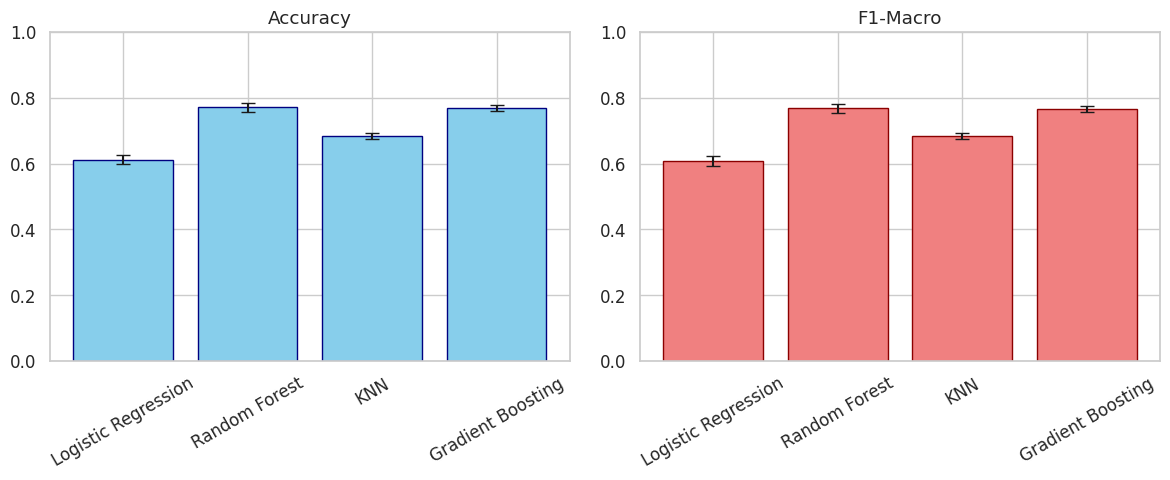

In [7]:
df_cv = pd.DataFrame(cv_results).T[['acc', 'f1', 'acc_std', 'f1_std']].reset_index()
df_cv.columns = ['Model', 'Accuracy', 'F1-Macro', 'Acc_Std', 'F1_Std']

fig, axes = plt.subplots(1, 2, figsize = (12, 5))
# строим барплоты чтобы сравнить модели
# высота столбика - среднее метрика по 5 фолдам чем выше тем лучше
# усы - стандартное отклонение, показывает насколько модель стабильна   
axes[0].bar(df_cv['Model'], df_cv['Accuracy'], yerr=df_cv['Acc_Std'], 
            capsize=5, color='skyblue', edgecolor='navy')
axes[0].set_title('Accuracy')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1)

axes[1].bar(df_cv['Model'], df_cv['F1-Macro'], yerr=df_cv['F1_Std'], 
            capsize=5, color='lightcoral', edgecolor='darkred')
axes[1].set_title('F1-Macro')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [8]:
best_model_name = df_cv.loc[df_cv['F1-Macro'].idxmax(), 'Model']
print(f"Лучшая модель по кросс-валидации: {best_model_name}")

from sklearn.model_selection import GridSearchCV
# делаем подбор гиперпараметров под каждую модель в случае ее успеха 
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 150], # кол-во деревьев в лесу
        'max_depth': [10,15, None], # максимальная глубина каждого дерева, ограничения нужны чтобы не было переобучения
        'min_samples_split': [2, 5] # минимальное кол-во объектов в узле, чтобы разделить его дальше 
    }
    best_model = RandomForestClassifier(random_state = 42)

elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10], # регуляризация: маленькая - недообучение, большая - переобучение
        'solver': ['lbfgs', 'saga'], # мат. алгоритм, который ищет минимум функции потерь
        'max_iter': [1000] # кол-во итераций
    }
    best_model = LogisticRegression(random_state = 42)

elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 150], # также кол-во деревьев - этапов бустинга 
        'learning_rate': [0.05, 0.1], # скорость обучения, чем он меньше тем больше деревьев нужно, и тем выше качество в итоге 
        'max_depth': [3, 5] # максимальная глубина, спецаильно маленькая глубина чтобы учились последовательно 
    }
    best_model = GradientBoostingClassifier(random_state = 42)
else:
    param_grid = {
        'n_neighbors': [5, 7, 9], # кол-во соседей
        'weights': ['uniform', 'distance'] # веса: первый - голос всех 7 соседей = 1, второй - голос ближайшего соседа весит больше чем 7 дальних
    }
    best_model = KNeighborsClassifier()

print(f"Запускаем GridSearch для {best_model_name}...")
grid = GridSearchCV(best_model, param_grid, cv=3, scoring='f1_macro', n_jobs=-1) # берем каждую возможную комбинацию параметров и прогоняем через кросс-валидацию
grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"F1 на валидации: {grid.best_score_:.4f}")

best_model = grid.best_estimator_ # готовая обученная модель с лучшими параметрами

Лучшая модель по кросс-валидации: Random Forest
Запускаем GridSearch для Random Forest...
Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
F1 на валидации: 0.7656


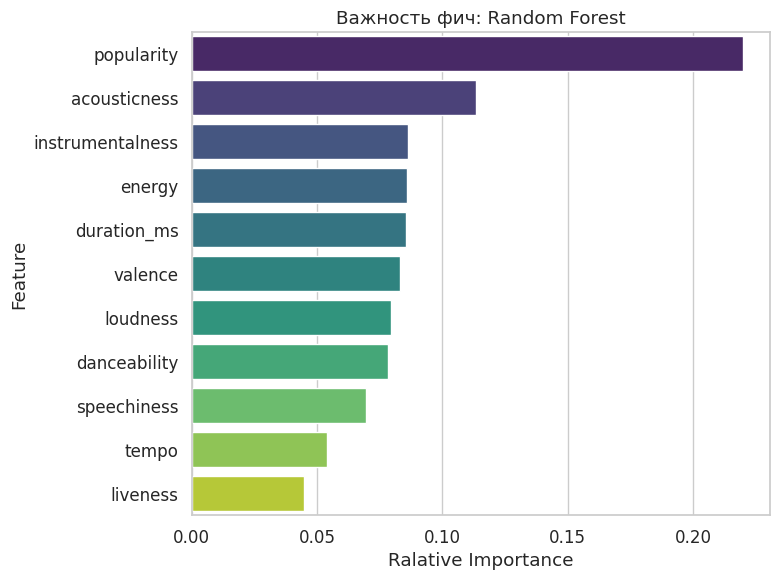

Топ-5 самых важных признаков для классификации:
popularity: 0.2198
acousticness: 0.1134
instrumentalness: 0.0863
energy: 0.0860
duration_ms: 0.0854

Финальная модель: Random Forest
Лучший F1-Macro на кросс-валидации: 0.7656


In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_ # оценка того, насколько каждый признак поомгал моедли принимать решения 
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending = False) # сортировка признаков, чтобы самые важные были сверху
    
    # строим горизонтальный барплот
    plt.figure(figsize=(8, 6))
    sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Важность фич: {best_model_name}')
    plt.xlabel('Ralative Importance')
    plt.tight_layout()
    plt.show()

    # выводим самое важное текстом
    print("Топ-5 самых важных признаков для классификации:")
    for _, row in feat_imp.head().iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")
else:
    print("У этой модели нет .feature_importances_ (LogReg или KNN).")
    print("Для линейных моделей можно смотреть коэффициенты (.coef_), для KNN — permutation importance.")

print(f"\nФинальная модель: {best_model_name}")
print(f"Лучший F1-Macro на кросс-валидации: {grid.best_score_:.4f}")

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok = True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

print('Артефакты сохранены в models/: best_model.pkl, scaler.pkl, label_encoder.pkl')

# 1 раз загружаю модель, чтобы чуть оптимизировать
model = joblib.load('models/best_model.pkl')
scaler = joblib.load('models/scaler.pkl')
le = joblib.load('models/label_encoder.pkl')

# функция предсказания 
# как прототип будущего API
def predict_genre(**features_dict):
    input_df = pd.DataFrame([features_dict]).reindex(columns=X.columns, fill_value = 0.0)

    input_scaled = scaler.transform(input_df)
    probas = model.predict_proba(input_scaled)[0]

    top_3_idx = np.argsort(probas)[::-1][:3]
    top_3 = [(le.inverse_transform([i])[0], round(probas[i] * 100, 1)) for i in top_3_idx]
    return top_3

print('Тест функции:')
print('Энергичный танцевальный трек:')
print(predict_genre(danceability = 0.85, energy = 0.9, valence = 0.7, tempo = 128, popularity = 85))
print('Медленный акустический трек:')
print(predict_genre(danceability = 0.3, energy = 0.2, valence = 0.4, tempo = 75, popularity = 30, acousticness = 0.85))

Артефакты сохранены в models/: best_model.pkl, scaler.pkl, label_encoder.pkl
Тест функции:
Энергичный танцевальный трек:
[('alt-rock', np.float64(38.0)), ('forro', np.float64(22.7)), ('acoustic', np.float64(14.0))]
Медленный акустический трек:
[('disney', np.float64(40.0)), ('acoustic', np.float64(20.0)), ('bluegrass', np.float64(14.0))]


Classification report:
               precision    recall  f1-score   support

     acoustic       0.58      0.57      0.57       200
     afrobeat       0.78      0.73      0.75       200
     alt-rock       0.76      0.83      0.79       200
      ambient       0.84      0.77      0.80       200
    bluegrass       0.70      0.75      0.72       200
     cantopop       0.69      0.66      0.67       200
chicago-house       0.95      0.96      0.96       199
       disney       0.74      0.64      0.68       200
        forro       0.86      0.94      0.90       199
        tango       0.82      0.90      0.86       200

     accuracy                           0.77      1998
    macro avg       0.77      0.77      0.77      1998
 weighted avg       0.77      0.77      0.77      1998



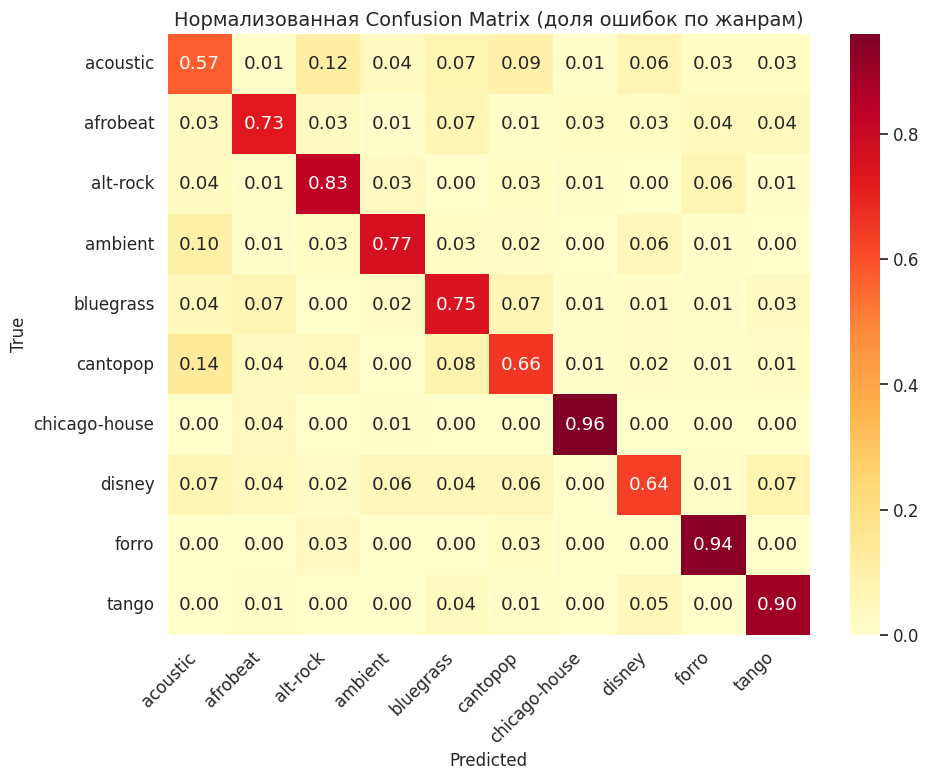


Топ-5 пар жанров, которые модель путает чаще всего:
cantopop → предсказан как acoustic (14.0% случаев)
acoustic → предсказан как alt-rock (11.5% случаев)
ambient → предсказан как acoustic (10.0% случаев)
acoustic → предсказан как cantopop (9.0% случаев)
cantopop → предсказан как bluegrass (8.0% случаев)


In [ ]:
# Анализ ошибок
y_pred = best_model.predict(X_test_scaled)
print('Classification report:')

print(classification_report(y_test, y_pred, target_names=class_names)) # выводит таблицу, где для каждого жанра посчитаны Precision, Recall и F1-score

cm = confusion_matrix(y_test, y_pred) # сама матрица ошибок 10 на 10
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # делаем нормализацию, чтобы частые жанры не перекрывали редкие

# строим нашу матрицу
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Нормализованная Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# автоматическая обработка ошибок и вывод 5 самых частых
print("\nТоп-5 пар жанров, которые модель путает чаще всего:")
errors = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_norm[i, j] > 0.05: 
            errors.append((class_names[i], class_names[j], cm_norm[i, j]))
# сортировочка
errors.sort(key=lambda x: -x[2])
for true_g, pred_g, pct in errors[:5]:
    print(f"{true_g} → предсказан как {pred_g} ({pct:.1%} случаев)")